=== RAW DATA ===
study_hours    1
attendance     0
prev_grade     0
final_score    1
dtype: int64
Pass rate: 65.8%

=== MODEL RESULTS ===
Accuracy : 58.3%
              precision    recall  f1-score   support

        Fail       0.33      0.25      0.29         8
        Pass       0.67      0.75      0.71        16

    accuracy                           0.58        24
   macro avg       0.50      0.50      0.50        24
weighted avg       0.56      0.58      0.57        24



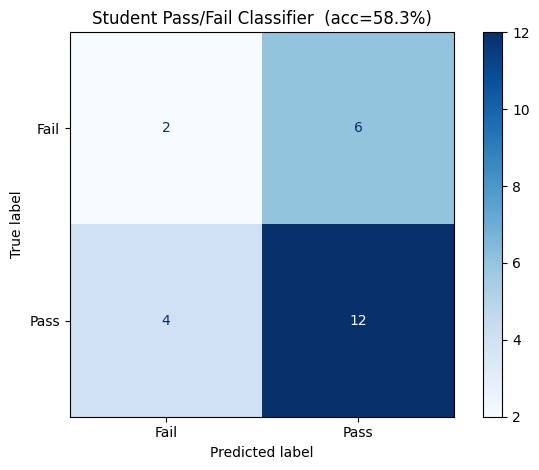

Pipeline complete. Model saved.


In [5]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_absolute_error, r2_score)
# == STAGE 1: Build and clean dataset ===============================
np.random.seed(7)
n = 120
raw = pd.DataFrame({
    'study_hours' : np.random.uniform(1, 10, n),
    'attendance'  : np.random.randint(50, 100, n),
    'prev_grade'  : np.random.choice(['A','B','C','D'], n),
    'final_score' : np.random.uniform(30, 100, n),
})
# Inject noise
raw.loc[5,  'final_score'] = np.nan
raw.loc[18, 'study_hours'] = np.nan
print('=== RAW DATA ===')
print(raw.isnull().sum())
# == STAGE 2: Clean ================================================
df = raw.copy()
df['final_score']=df['final_score'].fillna(df['final_score'].median())
df['study_hours']=df['study_hours'].fillna(df['study_hours'].median())
# == STAGE 3: Feature engineering ==================================
# Encode prev_grade as numeric (ordinal)
grade_map = {'A': 4, 'B': 3, 'C': 2, 'D': 1}
df['grade_num'] = df['prev_grade'].map(grade_map)
# Create binary target: Pass (1) if final_score >= 50
df['passed'] = (df['final_score'] >= 50).astype(int)
print(f'Pass rate: {df["passed"].mean()*100:.1f}%')
# == STAGE 4: Prepare X and y ======================================
features = ['study_hours', 'attendance', 'grade_num']
X = df[features].values
y = df['passed'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# == STAGE 5: Scale ================================================
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
# == STAGE 6: Train KNN classifier =================================
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
# == STAGE 7: Evaluate =============================================
y_pred = knn.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
mae    = mean_absolute_error(y_test, y_pred)
print()
print('=== MODEL RESULTS ===')
print(f'Accuracy : {acc*100:.1f}%')
print(classification_report(y_test, y_pred, target_names=['Fail','Pass']))
# == STAGE 8: Plot =================================================
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Fail','Pass'], cmap='Blues')
plt.title(f'Student Pass/Fail Classifier  (acc={acc*100:.1f}%)')
plt.tight_layout()
plt.savefig('pipeline_cm.png', dpi=150)
plt.show()
# == STAGE 9: Save =================================================
joblib.dump(knn,    'student_knn.pkl')
joblib.dump(scaler, 'student_scaler.pkl')
print('Pipeline complete. Model saved.')